In [ ]:
import pynapple as nap
from pathlib import Path

nwb_paths = [
    Path("/data_store2/neuropixels/nwb/NP95_B1/NP95_B1.nwb"), # tumor, 57, 1
    Path("/data_store2/neuropixels/nwb/NP114_B1/NP114_B1.nwb"), # tumor, 63, 1
    Path("/data_store2/neuropixels/nwb/NP113_B1/NP113_B1.nwb"), # tumor, 50, 1 (just show first 50)
    Path("/data_store2/neuropixels/nwb/NP136_B1/NP136_B1.nwb"), # tumor, 36, 1
    Path("/data_store2/neuropixels/nwb/NP147_B2/NP147_B2.nwb"), # tumor, 61, 1
    Path("/data_store2/neuropixels/nwb/uncorrected/NP116_B1/NP116_B1.nwb"), # opercular, 33, 1
    Path("/data_store2/neuropixels/nwb/NP137_B1/NP137_B1.nwb"), # opercular, 36, imec0
    Path("/data_store2/neuropixels/nwb/NP139_B1/NP139_B1.nwb"), # opercular, 44, imec0
    Path("/data_store2/neuropixels/nwb/NP139_B2/NP139_B2.nwb"), # opercuar, 51, imec0
    Path("/data_store2/neuropixels/nwb/NP153_B1/NP153_B1.nwb"), # opercular, 47, 1
]

subj_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
yield_list = [57, 63, 50, 36, 61, 33, 36, 44, 51, 47]
opercular_list = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]

In [ ]:
import fnmatch
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.decomposition import FastICA
from scipy.linalg import norm
from scipy.stats import kstest

def imec_key_sorter(key):
    # Extract the number after 'imec', default to a large number if not found
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

# loop through all nwb files
for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()

    # find the spike TsGroup objects, number various based on recording apparatus
    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    # Preferentially select keys containing 'KS4'; if none, use all keys
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    # Preferentially select keys containing 'Th='; if none, use all keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    # Exclude keys that include 'sentgen' or '_auto'
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    # If the path contains NP139, only select imec0
    if "NP139" in str(nwb_paths[i]) or "NP137" in str(nwb_paths[i]) or "NP113" in str(nwb_paths[i]):
        keys = [key for key in keys if "imec0" in key]
    # Sort keys so that imec0 is first, then imec1, then imec2, etc.
    keys = sorted(keys, key=imec_key_sorter)
    
    # loop through all individual probes
    for s in range(len(keys)):
        print(keys[s])
        spike_times = data[keys[s]]
        
        # 1. filter to good neurons
        firingRates_all = spike_times.metadata["rate"]
        task_times = data["TaskTimes"]
        beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]

        # calculate ks stats
        start_time = task_times.start
        end_time = task_times.end
        ks_stats = np.zeros(len(spike_times))
        ks_pvals = np.zeros(len(spike_times))
        for u in range(len(spike_times)):
            # get spike times for this unit
            test = spike_times[u].as_series().index.values

            # The null hypothesis is that the spike times are uniformly distributed between start_time and end_time
            if len(test) > 1:
                min_time = start_time[0]
                max_time = end_time[-1]
                # Normalize spike times to [0, 1] for KS test against uniform
                normalized_spike_times = (test - min_time) / (max_time - min_time)
                ks_result = kstest(normalized_spike_times, 'uniform')
                ks_stats[u] = ks_result.statistic
                ks_pvals[u] = ks_result.pvalue
            else:
                ks_stats[u] = np.nan
                ks_pvals[u] = np.nan

        # now do ISI calculation
        violationThreshold = 3/1000 #for 3 ms isi refractory period, what used before, middle of range that kilosort cites
        violationPct = np.zeros(len(spike_times))
        for u in range(len(spike_times)):
            unit = spike_times[u]
            unit = unit.as_series().index
            if len(unit) < 100:
                violationPct[u] = 1 
            else:
                isi = unit.diff()[1:len(unit)]
                violations = np.where(isi<violationThreshold)
                violations = np.array(violations)
                violationPct[u] = violations.size/len(isi)

        # now apply masks
        if "KSLabel" in spike_times.metadata:
            KSLabels = spike_times.metadata["KSLabel"]
        else:
            KSLabels = spike_times.metadata["quality"]
        firingRates = firingRates_beh
        mask1 = violationPct<3/100 # throwing out neurons with > 3% isi violations with isi = 3 ms; lose quite a bit with 5 ms esp when including cdf stats
        mask2 = firingRates>0.5 # firing rate > 0.5 ms during all behavior epochs
        mask3 = KSLabels!="noise" # not noise per auto label
        mask4 = ks_stats < 0.3 # KS stat < 0.3 (stability across recording)
        mask = mask1 & mask2 & mask3 & mask4
        indicesFinal = firingRates.index[mask]
        spike_times_good = spike_times_beh[indicesFinal]
        print(f"Number of good neurons: {len(spike_times_good)}")


NP95_B1_g0_imec1


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 57
NP114_B1_g0_imec0


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/base_class.py:60: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/base_class.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 63
NP132_B3_g0_imec0_KS4_Th=8


...

Number of good neurons: 44
NP139_B2_g0_imec0_KS4


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/base_class.py:60: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/base_class.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 51
NP153_B1_g0_imec0_KS4_Th=8


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 47


In [57]:
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
import cv2
from collections import defaultdict

def create_neuron_activity_video(nwb_paths, subj_list, yield_list, opercular_list, 
                                duration_seconds=10, start_offset_seconds=0, speed_factor=1.0, 
                                output_filename="neuron_activity.mp4", fps=30):
    """
    Create a video showing neuron activity across all sessions.
    
    Parameters:
    - nwb_paths: List of paths to NWB files
    - subj_list: List of subject IDs
    - yield_list: List of neuron counts per session
    - opercular_list: List of opercular status (0 or 1) per session
    - duration_seconds: How many seconds of the recording to include in the video
    - start_offset_seconds: How many seconds from the start of recording to begin the video
    - speed_factor: Speed multiplier (1.0 = real time, 2.0 = 2x speed)
    - output_filename: Name of the output video file
    - fps: Frames per second for the video
    """
    
    # Collect all spike data organized by opercular status
    opercular_0_data = []  # List of (session_name, spike_times_group, neuron_count)
    opercular_1_data = []
    
    print("Loading spike data...")
    
    # Process each NWB file
    for i in range(len(nwb_paths)):
        data = nap.load_file(nwb_paths[i])
        keys = data.keys()

        # Find spike TsGroup objects
        template = "*imec*"
        keys = [key for key in keys if fnmatch.fnmatch(key, template)]
        
        # Apply filtering logic from the original code
        ks_keys = [key for key in keys if "KS4" in key]
        if ks_keys:
            keys = ks_keys
        th8_keys = [key for key in keys if "Th=8" in key]
        if th8_keys:
            keys = th8_keys
        else:
            th_keys = [key for key in keys if "Th=" in key]
            if th_keys:
                keys = th_keys
                
        template_sentgen = "*sentgen*"
        template_auto = "*_auto*"
        keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
        
        if "NP139" in str(nwb_paths[i]) or "NP137" in str(nwb_paths[i]) or"NP113" in str(nwb_paths[i]):
            keys = [key for key in keys if "imec0" in key]
            
        keys = sorted(keys, key=imec_key_sorter)
        
        # Process each probe
        for s in range(len(keys)):
            print(f"Processing {keys[s]}")
            spike_times = data[keys[s]]
            
            # Apply the same filtering as in the original code
            firingRates_all = spike_times.metadata["rate"]
            task_times = data["TaskTimes"]
            beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
            spike_times_beh = spike_times.restrict(beh_epochs)
            firingRates_beh = spike_times_beh.metadata["rate"]

            # Calculate KS stats
            start_time = task_times.start
            end_time = task_times.end
            ks_stats = np.zeros(len(spike_times))
            ks_pvals = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                test = spike_times[u].as_series().index.values
                if len(test) > 1:
                    min_time = start_time[0]
                    max_time = end_time[-1]
                    normalized_spike_times = (test - min_time) / (max_time - min_time)
                    ks_result = kstest(normalized_spike_times, 'uniform')
                    ks_stats[u] = ks_result.statistic
                    ks_pvals[u] = ks_result.pvalue
                else:
                    ks_stats[u] = np.nan
                    ks_pvals[u] = np.nan

            # Calculate ISI violations
            violationThreshold = 3/1000
            violationPct = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                unit = spike_times[u]
                unit = unit.as_series().index
                if len(unit) < 100:
                    violationPct[u] = 1 
                else:
                    isi = unit.diff()[1:len(unit)]
                    violations = np.where(isi<violationThreshold)
                    violations = np.array(violations)
                    violationPct[u] = violations.size/len(isi)

            # Apply quality filters
            if "KSLabel" in spike_times.metadata:
                KSLabels = spike_times.metadata["KSLabel"]
            else:
                KSLabels = spike_times.metadata["quality"]
            firingRates = firingRates_beh
            mask1 = violationPct<3/100
            mask2 = firingRates>0.5
            mask3 = KSLabels!="noise"
            mask4 = ks_stats < 0.3
            mask = mask1 & mask2 & mask3 & mask4
            indicesFinal = firingRates.index[mask]
            spike_times_good = spike_times_beh[indicesFinal]
            
            # NP113: only keep first 50 neurons
            is_np113 = "NP113" in str(nwb_paths[i])
            if is_np113:
                # Only keep first 50 units
                unit_ids = list(spike_times_good.keys())
                if len(unit_ids) > 50:
                    # Restrict to first 50 units
                    selected_unit_ids = unit_ids[:50]
                    spike_times_good = spike_times_good[selected_unit_ids]
                neuron_count = min(len(spike_times_good), 50)
            else:
                neuron_count = len(spike_times_good)
            
            print(f"Number of good neurons: {len(spike_times_good)}")
            
            # Store data based on opercular status
            session_name = f"Session_{subj_list[i]}_{s}"
            if opercular_list[i] == 0:
                opercular_0_data.append((session_name, spike_times_good, neuron_count))
            else:
                opercular_1_data.append((session_name, spike_times_good, neuron_count))
    
    # Calculate total neurons and setup grid
    total_opercular_0_neurons = sum([count for _, _, count in opercular_0_data])
    total_opercular_1_neurons = sum([count for _, _, count in opercular_1_data])
    max_neurons_per_session = max(
        [min(count, 50) if "NP113" in session_name else count for session_name, _, count in opercular_0_data + opercular_1_data]
    ) if opercular_0_data + opercular_1_data else 0
    
    print(f"Tumor sessions: {len(opercular_0_data)}, total neurons: {total_opercular_0_neurons}")
    print(f"Control sessions: {len(opercular_1_data)}, total neurons: {total_opercular_1_neurons}")
    
    # Debug: Print session details
    print("\nDebug - Session details:")
    for i, (session_name, spike_times_group, neuron_count) in enumerate(opercular_0_data):
        print(f"Tumor session {i}: {session_name}, {neuron_count} neurons")
        if len(spike_times_group) > 0:
            unit_ids = list(spike_times_group.keys())
            print(f"  Unit IDs: {unit_ids[:10]}...")  # Show first 10 unit IDs
            print(f"  First neuron spikes: {len(spike_times_group[unit_ids[0]].as_series())} spikes")
    for i, (session_name, spike_times_group, neuron_count) in enumerate(opercular_1_data):
        print(f"Control session {i}: {session_name}, {neuron_count} neurons")
        if len(spike_times_group) > 0:
            unit_ids = list(spike_times_group.keys())
            print(f"  Unit IDs: {unit_ids[:10]}...")  # Show first 10 unit IDs
            print(f"  First neuron spikes: {len(spike_times_group[unit_ids[0]].as_series())} spikes")
    
    # Create the visualization with very compact layout
    fig, ax = plt.subplots(figsize=(6, 10))
    
    # Calculate layout dimensions
    tumor_sessions = len(opercular_0_data)
    control_sessions = len(opercular_1_data)
    gap_width = 12  # Gap between tumor and control sections
    
    total_width = tumor_sessions + gap_width + control_sessions
    ax.set_xlim(0, total_width)
    ax.set_ylim(0, max_neurons_per_session)
    ax.set_aspect('equal')
    
    # Remove all axes, ticks, and spines
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add y-axis labels showing neuron counts for each session
    # Tumor sessions - positioned to the left of the data
    for session_idx, (session_name, spike_times_group, neuron_count) in enumerate(opercular_0_data):
        ax.text(-0.5, neuron_count - 0.5, str(neuron_count), 
                ha='right', va='center', fontsize=16, color='red', fontweight='bold')
    
    # Control sessions - positioned further to the right to avoid overlap
    control_start_x = tumor_sessions + gap_width
    control_end_x = control_start_x + control_sessions - 1  # Rightmost column position
    for session_idx, (session_name, spike_times_group, neuron_count) in enumerate(opercular_1_data):
        ax.text(control_end_x + 1.0, neuron_count - 0.5, str(neuron_count), 
                ha='left', va='center', fontsize=16, color='blue', fontweight='bold')
    
    # Add labels with better positioning and total counts (reduced spacing)
    tumor_total = sum([count for _, _, count in opercular_0_data])
    control_total = sum([count for _, _, count in opercular_1_data])
    
    ax.text(tumor_sessions/2, max_neurons_per_session + 4, f'Tumor\n({tumor_total} neurons)', 
            ha='center', va='center', fontsize=18, fontweight='bold', color='red')
    ax.text(tumor_sessions + gap_width + control_sessions/2, max_neurons_per_session + 4, f'Control\n({control_total} neurons)', 
            ha='center', va='center', fontsize=18, fontweight='bold', color='blue')
    
    # Create grid rectangles (white background) - equal width, session-specific height
    rectangles = []
    neuron_positions = {}  # Maps (session_idx, neuron_idx) to rectangle
    
    # Tumor sessions (opercular = 0) - each session has its own height
    for session_idx, (session_name, spike_times_group, neuron_count) in enumerate(opercular_0_data):
        # If this is NP113, only show up to 50 neurons
        is_np113 = "NP113" in session_name
        n_neurons = min(neuron_count, 50) if is_np113 else neuron_count
        for neuron_idx in range(n_neurons):
            rect = Rectangle((session_idx, neuron_idx), 1, 1,  # Equal width and height
                           facecolor='white', edgecolor='lightgray', linewidth=0.5)
            ax.add_patch(rect)
            rectangles.append(rect)
            neuron_positions[(session_idx, neuron_idx)] = len(rectangles) - 1
    
    # Control sessions (opercular = 1) - positioned after gap, each session has its own height
    control_start_x = tumor_sessions + gap_width
    for session_idx, (session_name, spike_times_group, neuron_count) in enumerate(opercular_1_data):
        actual_x = control_start_x + session_idx
        # If this is NP113, only show up to 50 neurons (shouldn't happen for control, but for completeness)
        is_np113 = "NP113" in session_name
        n_neurons = min(neuron_count, 50) if is_np113 else neuron_count
        for neuron_idx in range(n_neurons):
            rect = Rectangle((actual_x, neuron_idx), 1, 1,  # Equal width and height
                           facecolor='white', edgecolor='lightgray', linewidth=0.5)
            ax.add_patch(rect)
            rectangles.append(rect)
            neuron_positions[(actual_x, neuron_idx)] = len(rectangles) - 1
    
    # Find the time range across all sessions
    all_start_times = []
    all_end_times = []
    
    for i in range(len(nwb_paths)):
        data = nap.load_file(nwb_paths[i])
        task_times = data["TaskTimes"]
        all_start_times.append(task_times.start[0])
        all_end_times.append(task_times.end[-1])
    
    global_start_time = min(all_start_times)
    global_end_time = max(all_end_times)
    total_recording_duration = global_end_time - global_start_time
    
    # Calculate video start and end times based on user parameters
    video_start_time = global_start_time + start_offset_seconds
    video_end_time = video_start_time + duration_seconds
    
    # Ensure we don't exceed the recording bounds
    if video_start_time > global_end_time:
        raise ValueError(f"Start offset ({start_offset_seconds}s) exceeds recording duration ({total_recording_duration:.2f}s)")
    
    if video_end_time > global_end_time:
        print(f"Warning: Requested duration ({duration_seconds}s) exceeds remaining recording time. Adjusting to {global_end_time - video_start_time:.2f}s")
        video_end_time = global_end_time
        duration_seconds = video_end_time - video_start_time
    
    # Calculate frame parameters based on video duration
    total_frames = int(duration_seconds * fps / speed_factor)
    time_per_frame = duration_seconds / total_frames
    
    print(f"Total recording duration: {total_recording_duration:.2f} seconds")
    print(f"Video start time: {video_start_time:.2f}s (offset: {start_offset_seconds}s)")
    print(f"Video duration: {duration_seconds:.2f} seconds")
    print(f"Video end time: {video_end_time:.2f}s")
    print(f"Creating video with {total_frames} frames...")
    print(f"Time per frame: {time_per_frame:.4f} seconds")
    
    def animate(frame):
        current_time = video_start_time + frame * time_per_frame
        
        # Reset all rectangles to white
        for rect in rectangles:
            rect.set_facecolor('white')
        
        # Check for spikes in tumor sessions (opercular = 0)
        for session_idx, (session_name, spike_times_group, neuron_count) in enumerate(opercular_0_data):
            is_np113 = "NP113" in session_name
            n_neurons = min(neuron_count, 50) if is_np113 else neuron_count
            unit_ids = list(spike_times_group.keys())
            for unit_idx in range(min(n_neurons, len(unit_ids))):
                if unit_idx >= len(unit_ids):
                    break
                unit_id = unit_ids[unit_idx]
                try:
                    neuron_spikes = spike_times_group[unit_id].as_series().index.values
                    # Check if there's a spike within the current time window
                    spike_window = 0.05  # 50ms window
                    spikes_in_window = neuron_spikes[
                        (neuron_spikes >= current_time - spike_window/2) & 
                        (neuron_spikes <= current_time + spike_window/2)
                    ]
                    
                    if len(spikes_in_window) > 0:
                        rect_idx = neuron_positions.get((session_idx, unit_idx))
                        if rect_idx is not None:
                            rectangles[rect_idx].set_facecolor('black')
                except Exception as e:
                    pass  # Skip if neuron data is not available
        
        # Check for spikes in control sessions (opercular = 1)
        control_start_x = tumor_sessions + gap_width
        for session_idx, (session_name, spike_times_group, neuron_count) in enumerate(opercular_1_data):
            actual_x = control_start_x + session_idx
            is_np113 = "NP113" in session_name
            n_neurons = min(neuron_count, 50) if is_np113 else neuron_count
            unit_ids = list(spike_times_group.keys())
            for unit_idx in range(min(n_neurons, len(unit_ids))):
                if unit_idx >= len(unit_ids):
                    break
                unit_id = unit_ids[unit_idx]
                try:
                    neuron_spikes = spike_times_group[unit_id].as_series().index.values
                    spike_window = 0.05  # 50ms window
                    spikes_in_window = neuron_spikes[
                        (neuron_spikes >= current_time - spike_window/2) & 
                        (neuron_spikes <= current_time + spike_window/2)
                    ]
                    
                    if len(spikes_in_window) > 0:
                        rect_idx = neuron_positions.get((actual_x, unit_idx))
                        if rect_idx is not None:
                            rectangles[rect_idx].set_facecolor('black')
                except Exception as e:
                    pass
        
        # Update title with current time and video progress
        elapsed_time = current_time - video_start_time
        ax.set_title(f'Recording Time: {current_time:.2f}s (Elapsed: {elapsed_time:.2f}s, 4x speed)', fontsize=14)
        
        return rectangles
    
    # Create animation
    anim = animation.FuncAnimation(fig, animate, frames=total_frames, 
                                  interval=1000/fps, blit=False, repeat=True)
    
    # Save video
    print(f"Saving video to {output_filename}...")
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=fps, metadata=dict(artist='Neuron Activity Visualization'), bitrate=1800)
    anim.save(output_filename, writer=writer)
    
    print("Video creation complete!")
    return anim


Creating neuron activity video...
Duration: 60 seconds
Start offset: 600 seconds
Speed factor: 4x
Output file: neuron_activity_visualization.mp4
Loading spike data...
Processing NP95_B1_g0_imec1


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 57
Processing NP114_B1_g0_imec0


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/base_class.py:60: UserWarning: Some epochs have no duration
  self.time_support = IntervalSet(start=self.index[0], end=self.index[-1])
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/base_class.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  self.rate = self.index.shape[0] / np.sum(
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 63
Processing NP113_B1_g0_imec0_KS4_Th=8


...

Number of good neurons: 51
Processing NP153_B1_g0_imec0_KS4_Th=8


/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(


Number of good neurons: 47
Tumor sessions: 5, total neurons: 264
Control sessions: 5, total neurons: 211

Debug - Session details:
Tumor session 0: Session_1_0, 57 neurons
  Unit IDs: [2, 5, 6, 7, 9, 10, 11, 12, 14, 18]...
  First neuron spikes: 2654 spikes
Tumor session 1: Session_2_0, 63 neurons
  Unit IDs: [0, 1, 14, 21, 32, 34, 37, 39, 42, 49]...
  First neuron spikes: 3841 spikes
Tumor session 2: Session_3_0, 50 neurons
  Unit IDs: [7, 9, 10, 11, 12, 13, 16, 19, 20, 23]...
  First neuron spikes: 19867 spikes
Tumor session 3: Session_4_0, 33 neurons
  Unit IDs: [43, 55, 59, 77, 87, 88, 97, 109, 113, 122]...
  First neuron spikes: 2569 spikes
Tumor session 4: Session_5_0, 61 neurons
  Unit IDs: [41, 47, 52, 57, 59, 63, 73, 74, 78, 82]...
  First neuron spikes: 3329 spikes
Control session 0: Session_6_0, 33 neurons
  Unit IDs: [1, 18, 50, 60, 62, 84, 93, 107, 113, 117]...
  First neuron spikes: 1726 spikes
Control session 1: Session_7_0, 36 neurons
  Unit IDs: [39, 46, 50, 64, 68, 75

/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' or key indexing to access metadata.
  warnings.warn(
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts and ends are equal. Removing 1 microsecond!
  data = nap.IntervalSet(df)
/userdata/ekato/miniforge3/envs/se2nwb/lib/python3.10/site-packages/pynapple/core/metadata_class.py:188: UserWarning: Metadata name 'Task name' contains a special character, and cannot be accessed as an attribute. Use 'get_info()' o

Total recording duration: 2602.00 seconds
Video start time: 600.00s (offset: 600s)
Video duration: 60.00 seconds
Video end time: 660.00s
Creating video with 450 frames...
Time per frame: 0.1333 seconds
Saving video to neuron_activity_visualization.mp4...
Video creation complete!


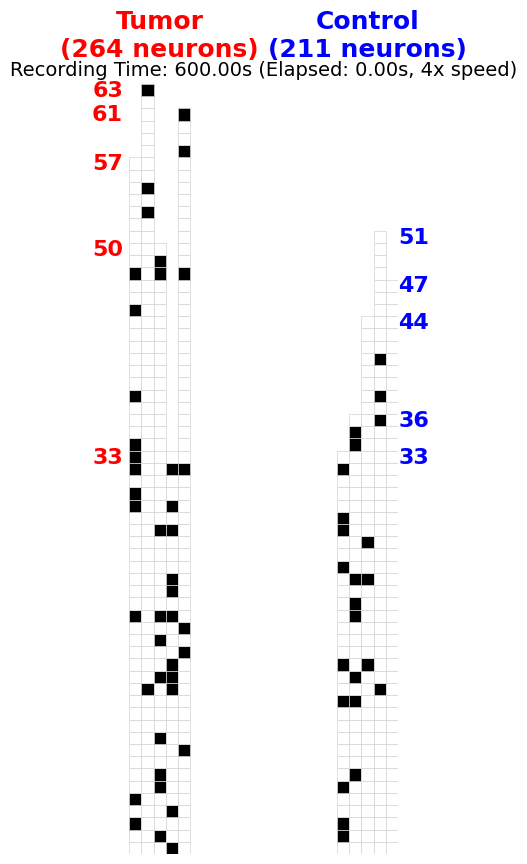

In [58]:
# Example usage of the video creation function
# You can adjust these parameters:

# Duration and timing settings
duration_seconds = 60      # How many seconds of recording to include
start_offset_seconds = 600    # How many seconds from start of recording to begin
speed_factor = 4           # Speed multiplier (2.0 = 2x speed)

# Video settings
output_filename = "neuron_activity_visualization.mp4"
fps = 30  # Frames per second

print("Creating neuron activity video...")
print(f"Duration: {duration_seconds} seconds")
print(f"Start offset: {start_offset_seconds} seconds")
print(f"Speed factor: {speed_factor}x")
print(f"Output file: {output_filename}")

# Create the video
anim = create_neuron_activity_video(
    nwb_paths=nwb_paths,
    subj_list=subj_list, 
    yield_list=yield_list,
    opercular_list=opercular_list,
    duration_seconds=duration_seconds,
    start_offset_seconds=start_offset_seconds,
    speed_factor=speed_factor,
    output_filename=output_filename,
    fps=fps
)


In [ ]:
# Additional customization options

def create_custom_neuron_video(duration=10, start_offset=0, speed=1.0, spike_window_ms=50, 
                              output_name="custom_neuron_video.mp4"):
    """
    Create a customized neuron activity video with additional parameters.
    
    Parameters:
    - duration: How many seconds of recording to include
    - start_offset: How many seconds from start of recording to begin
    - speed: Speed factor (1.0 = real time)
    - spike_window_ms: Time window in milliseconds for spike detection
    - output_name: Output filename
    """
    
    print(f"Creating custom video:")
    print(f"  Duration: {duration} seconds")
    print(f"  Start offset: {start_offset} seconds")
    print(f"  Speed: {speed}x")
    print(f"  Spike window: {spike_window_ms}ms")
    print(f"  Output: {output_name}")
    
    # Create the video with custom parameters
    anim = create_neuron_activity_video(
        nwb_paths=nwb_paths,
        subj_list=subj_list,
        yield_list=yield_list, 
        opercular_list=opercular_list,
        duration_seconds=duration,
        start_offset_seconds=start_offset,
        speed_factor=speed,
        output_filename=output_name,
        fps=30
    )
    
    return anim

# Example: Create a 5-second video starting at 60 seconds
# early_video = create_custom_neuron_video(duration=5, start_offset=60, speed=4.0, output_name="early_activity.mp4")

# Example: Create a 30-second video starting from the beginning at half speed
# detailed_video = create_custom_neuron_video(duration=30, start_offset=0, speed=0.5, output_name="detailed_activity.mp4")


In [ ]:
# Quick test function to verify everything works
def test_video_generation():
    """
    Test the video generation with a short, fast video to verify functionality.
    """
    print("Testing video generation with a short sample...")
    
    try:
        # Create a very short test video
        test_anim = create_neuron_activity_video(
            nwb_paths=nwb_paths,
            subj_list=subj_list,
            yield_list=yield_list,
            opercular_list=opercular_list,
            duration_seconds=3,  # Very short for testing
            start_offset_seconds=0,  # Start from beginning
            speed_factor=5.0,    # Fast speed for testing
            output_filename="test_neuron_video.mp4",
            fps=15  # Lower fps for faster generation
        )
        
        print("✅ Test video generation successful!")
        print("You can now create videos with your desired duration, start offset, and speed parameters.")
        return test_anim
        
    except Exception as e:
        print(f"❌ Error during test video generation: {e}")
        print("Please check your data paths and dependencies.")
        return None

# Uncomment the line below to run the test
# test_result = test_video_generation()
